<a href="https://colab.research.google.com/github/Eugeacosta/Analisis_EDA_Logistica_Inversa/blob/main/Analisis_puntos_de_dolor_inversas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



> **ANALISIS DE PUNTOS DE DOLOR
 LOGISTICA INVERSA**



Hipótesis 1 (Saturación Operativa): Los días con picos de solicitudes de retiro en el AMBA correlacionan fuertemente con una caída del % de SLA y el aumento de "falsos escaneos".

Hipótesis 2 (Agujeros de Sistema): Los retiros "fantasma" (que tienen entrega pero no figuran como "Retirados") no ocurren al azar,

 Hipótesis 3: Las inconsistencias de escaneo se concentran en canalizadores y sucursales específicas.


In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.preprocessing import LabelEncoder

In [69]:
sns.set_theme(style="whitegrid")

nombre_archivo = '/consolidado inversas.csv'

try:
    df = pd.read_csv(nombre_archivo, sep=';', encoding='latin1', decimal=',')
except:

    df = pd.read_csv(nombre_archivo, encoding='utf-8')
print("Primeras 5 filas del dataset:")
display(df.head())
print("\n--- Información técnica de las columnas ---")
df.info()

Primeras 5 filas del dataset:


/tmp/ipykernel_31193/3427293430.py:6: DtypeWarning: Columns (0,13,14,15,17,19,25,46) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(nombre_archivo, sep=';', encoding='latin1', decimal=',')


,Equipo,Fecha Imposición,AP,Cliente AP,Fecha POD,Fecha HU,CP,Status,Motivo,Fecha 1er Visita,...,Clasif_Inversa_Propia,Clasif_H2H_Propia,ID cliente,Aps H2H ciclo,Eco Pieza,Tipo,Centro de stock,SLA_48hs_Punta_a_Punta,Total Dias Retiro Punta a Punta,Performance PaP
0,1222055205,6/8/2025 00:00,40037451,PICKIT ARGENTINA,14/8/2025 00:00,7/8/2025 00:00,1868.0,FINALIZADA,Entregado,14/8/2025 00:00,...,Inversa,No H2H,EC40001416730,NaN,45231149512,Sit. Normal,A001,Delay,6.0,Delay
1,1222432335,15/8/2025 00:00,40037451,PICKIT ARGENTINA,20/8/2025 00:00,16/8/2025 00:00,1868.0,FINALIZADA,Entregado,20/8/2025 00:00,...,Inversa,No H2H,EC40001459971,NaN,45261396232,Sit. Normal,A001,Delay,6.0,Delay
2,1222876960,20/8/2025 00:00,40037451,PICKIT ARGENTINA,27/8/2025 00:00,21/8/2025 00:00,1868.0,FINALIZADA,Entregado,27/8/2025 00:00,...,Inversa,No H2H,EC40001525409,NaN,45305415803,Sit. Normal,A001,Delay,6.0,Delay
3,1222956028,20/8/2025 00:00,40037451,PICKIT ARGENTINA,27/8/2025 00:00,21/8/2025 00:00,1868.0,FINALIZADA,Entregado,27/8/2025 00:00,...,Inversa,No H2H,EC40001541044,NaN,45313698222,Sit. Normal,A001,Delay,5.0,Delay
4,1223098764,22/8/2025 00:00,40037451,PICKIT ARGENTINA,27/8/2025 00:00,23/8/2025 00:00,1868.0,FINALIZADA,Entregado,27/8/2025 00:00,...,Inversa,No H2H,EC40001561694,NaN,45312097336,Sit. Normal,A001,Delay,3.0,On Time



--- Información técnica de las columnas ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60629 entries, 0 to 60628
Data columns (total 52 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Equipo                           60629 non-null  object 
 1   Fecha Imposición                 59936 non-null  object 
 2   AP                               60629 non-null  int64  
 3   Cliente AP                       60629 non-null  object 
 4   Fecha POD                        58110 non-null  object 
 5   Fecha HU                         59348 non-null  object 
 6   CP                               60421 non-null  float64
 7   Status                           60629 non-null  object 
 8   Motivo                           60629 non-null  object 
 9   Fecha 1er Visita                 58211 non-null  object 
 10  Motivo 1er Visita                60629 non-null  object 
 11  Provincia                        60

In [70]:

# Configuración de estilo
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

# CARGA DE DATOS (Asegúrate de que el nombre coincida con tu archivo subido)
df = pd.read_csv('/consolidado inversas.csv', sep=';', encoding='latin1', decimal=',')

# CONVERSIÓN DE FECHAS
date_columns = ['Fecha Solicitud Retiro', 'Fecha POD', 'Fecha Imposición', 'Fecha de Creación (Retiro)']
for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# FILTRO DE SEGURIDAD: Excluimos errores de SAP (fechas <= 2020) y nulos en inicio
df_clean = df[(df['Fecha POD'].dt.year > 2020) & (df['Fecha Solicitud Retiro'].notnull())].copy()

# Creamos variables de tiempo para el análisis
df_clean['Mes'] = df_clean['Fecha Solicitud Retiro'].dt.to_period('M').astype(str)
df_clean['Dia_Semana'] = df_clean['Fecha Solicitud Retiro'].dt.day_name()

print(f"Dataset listo. Registros procesables: {len(df_clean)}")

/tmp/ipykernel_31193/2300944990.py:6: DtypeWarning: Columns (0,13,14,15,17,19,25,46) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/consolidado inversas.csv', sep=';', encoding='latin1', decimal=',')
/tmp/ipykernel_31193/2300944990.py:11: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df[col] = pd.to_datetime(df[col], errors='coerce')


Dataset listo. Registros procesables: 22932


Alerta operativa: Se detectaron 19353 pedidos entregados sin escaneo de retiro inicial.
Esto representa el 84.4% de la operación de inversas auditada.


<Figure size 1400x800 with 0 Axes>

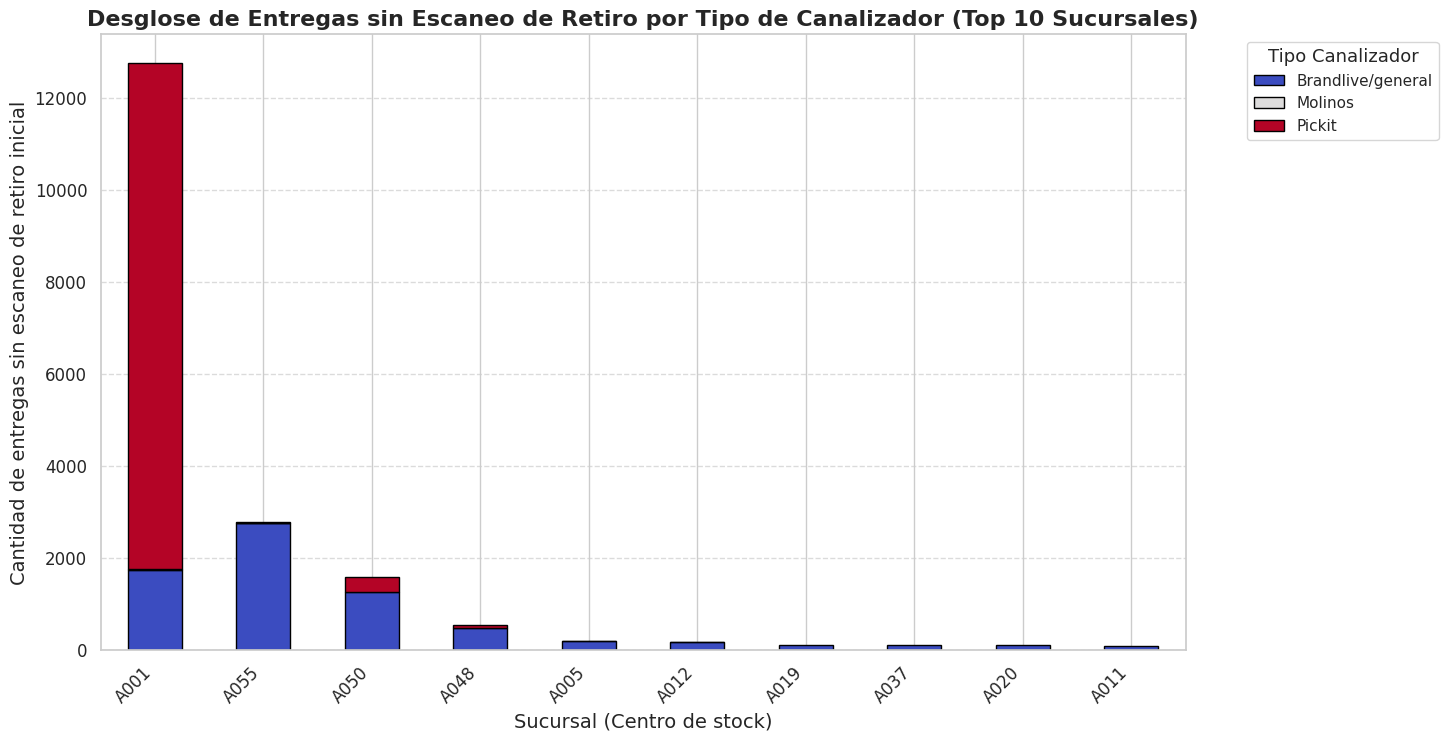

In [71]:

# 1. IDENTIFICACIÓN DE FUGAS (Pedidos entregados sin escaneo de retiro inicial)
# Buscamos pedidos que avanzaron (tienen Imposición o POD nulos) pero NO tienen actualización de estado de retiro
fugas = df_clean[
    (df_clean['Fecha Imposición'].notnull() | df_clean['Fecha POD'].notnull()) &
    (df_clean['Fecha de RAO (Retiro)'].isnull()) &
    (df_clean['Retiro 1'].isnull())
]

total_fugas = len(fugas)
porcentaje_fugas = (total_fugas / len(df_clean)) * 100

print(f"==============================================================================")
print(f"Alerta operativa: Se detectaron {total_fugas} pedidos entregados sin escaneo de retiro inicial.")
print(f"Esto representa el {porcentaje_fugas:.1f}% de la operación de inversas auditada.")
print(f"==============================================================================")

# 2. SELECCIÓN DE LAS TOP 10 SUCURSALES CON MÁS FUGAS
top10_centro_stock_names = fugas['Centro de stock'].value_counts().head(10).index
fugas_top10 = fugas[fugas['Centro de stock'].isin(top10_centro_stock_names)].copy()

# 3. Sucursal vs Tipo Canalizador

ct_top10_canalizador = pd.crosstab(fugas_top10['Centro de stock'], fugas_top10['Tipo_Canalizador'])


ct_top10_canalizador = ct_top10_canalizador.loc[ct_top10_canalizador.sum(axis=1).sort_values(ascending=False).index]


plt.figure(figsize=(14, 8))
ct_top10_canalizador.plot(
    kind='bar',
    stacked=True,
    figsize=(14, 8),
    cmap='coolwarm',
    edgecolor='black'
)

# Títulos
plt.title('Desglose de Entregas sin Escaneo de Retiro por Tipo de Canalizador (Top 10 Sucursales)', fontsize=16, fontweight='bold')
plt.xlabel('Sucursal (Centro de stock)', fontsize=14)
plt.ylabel('Cantidad de entregas sin escaneo de retiro inicial', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title='Tipo Canalizador', title_fontsize='13', fontsize='11', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


Total de pedidos entregados sin registro de Imposición: 5311


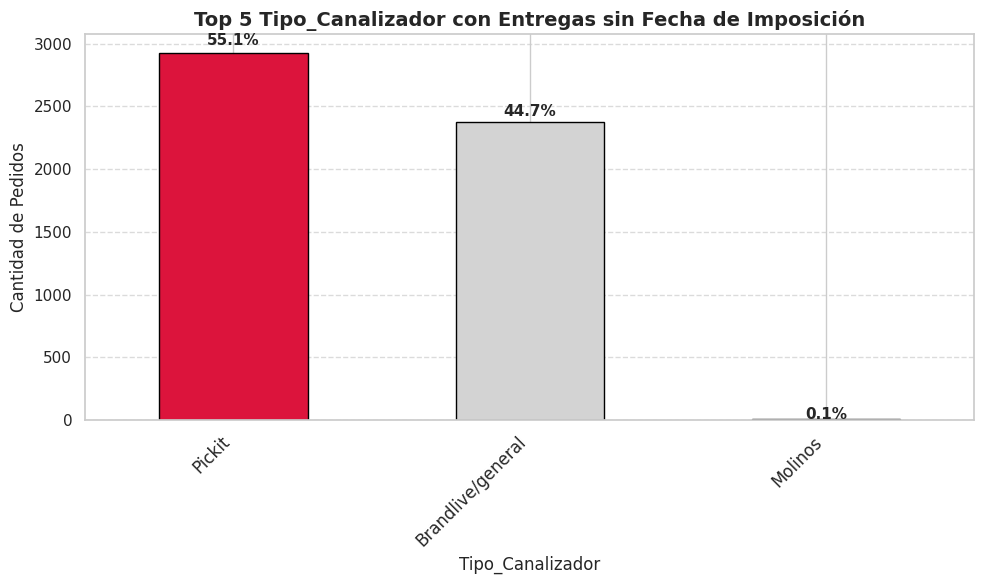

In [72]:
# ==============================================================================
# FOCUS: EL FENÓMENO "PICKIT" Y LAS IMPOSICIONES FALTANTES
# Hipótesis: La falta de escaneo de imposición es una práctica masiva asociada a clientes/canalizadores específicos.
# ==============================================================================

# 1. Aislamos los casos que TIENEN POD pero NO TIENEN Imposición
sin_imposicion = df_clean[
    (df_clean['Fecha POD'].notnull()) &
    (df_clean['Fecha Imposición'].isnull())
].copy()

print(f"Total de pedidos entregados sin registro de Imposición: {len(sin_imposicion)}")



columna_analisis = 'Tipo_Canalizador'
top_infractores = sin_imposicion[columna_analisis].value_counts().head(5)


plt.figure(figsize=(10, 6))

colores = ['crimson'] + ['lightgrey'] * (len(top_infractores) - 1)

ax = top_infractores.plot(kind='bar', color=colores, edgecolor='black')

plt.title(f'Top 5 {columna_analisis} con Entregas sin Fecha de Imposición', fontsize=14, fontweight='bold')
plt.ylabel('Cantidad de Pedidos', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=12)


total_sin_impo = len(sin_imposicion)
for i, v in enumerate(top_infractores):
    porcentaje = (v / total_sin_impo) * 100
    plt.text(i, v + (v * 0.02), f"{porcentaje:.1f}%", ha='center', fontweight='bold', fontsize=11)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Entrenando algoritmo de Machine Learning...


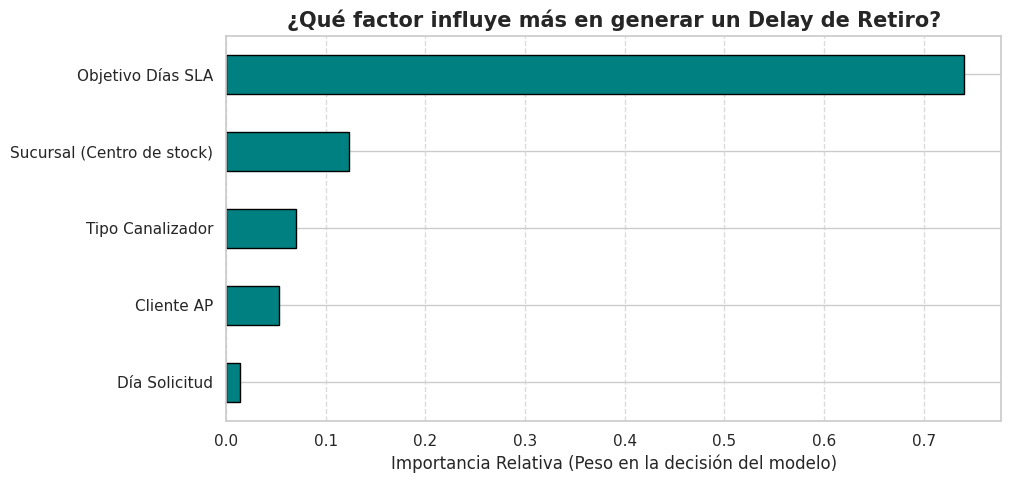

Entrenamiento finalizado. Mirá la barra más larga en el gráfico: ese es el mayor factor de riesgo.


In [73]:
# ==============================================================================
# MACHINE LEARNING 1: FEATURE IMPORTANCE (RANDOM FOREST)
# Objetivo: Identificar qué factores causan realmente los Delays en el SLA.
# ==============================================================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

print("Entrenando algoritmo de Machine Learning...")

# 1. Filtramos y preparamos los datos sin nulos para las columnas clave
cols_ml = ['Centro de stock', 'Cliente AP', 'Tipo_Canalizador', 'Dia_Semana', 'dias_sla', 'Performance PaP']
df_ml = df_clean.dropna(subset=cols_ml).copy()


for col in ['Centro de stock', 'Cliente AP', 'Tipo_Canalizador', 'Dia_Semana']:
    df_ml[col] = df_ml[col].astype(str)

# 2. Transformamos el texto en números para que el algoritmo lo entienda
le_Centro_de_stock = LabelEncoder()
le_cliente = LabelEncoder()
le_canalizador = LabelEncoder()
le_dia = LabelEncoder()

df_ml['Centro de stock_n'] = le_Centro_de_stock.fit_transform(df_ml['Centro de stock'])
df_ml['Cliente_n'] = le_cliente.fit_transform(df_ml['Cliente AP'])
df_ml['Canal_n'] = le_canalizador.fit_transform(df_ml['Tipo_Canalizador'])
df_ml['Dia_n'] = le_dia.fit_transform(df_ml['Dia_Semana'])

# 3. Target: 1 si es Delay, 0 si es On Time
df_ml['Target'] = df_ml['Performance PaP'].apply(lambda x: 1 if x == 'Delay' else 0)

# Variables predictoras (lo que el modelo va a analizar)
X = df_ml[['Centro de stock_n', 'Cliente_n', 'Canal_n', 'Dia_n', 'dias_sla']]
y = df_ml['Target']


rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)
rf_model.fit(X, y)


importancias = pd.Series(rf_model.feature_importances_, index=['Sucursal (Centro de stock)', 'Cliente AP', 'Tipo Canalizador', 'Día Solicitud', 'Objetivo Días SLA'])
importancias = importancias.sort_values(ascending=True)

plt.figure(figsize=(10, 5))
importancias.plot(kind='barh', color='teal', edgecolor='black')
plt.title('¿Qué factor influye más en generar un Delay de Retiro?', fontsize=15, fontweight='bold')
plt.xlabel('Importancia Relativa (Peso en la decisión del modelo)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print("Entrenamiento finalizado. Mirá la barra más larga en el gráfico: ese es el mayor factor de riesgo.")

Calculando la brecha entre el SLA exigido y la realidad operativa...


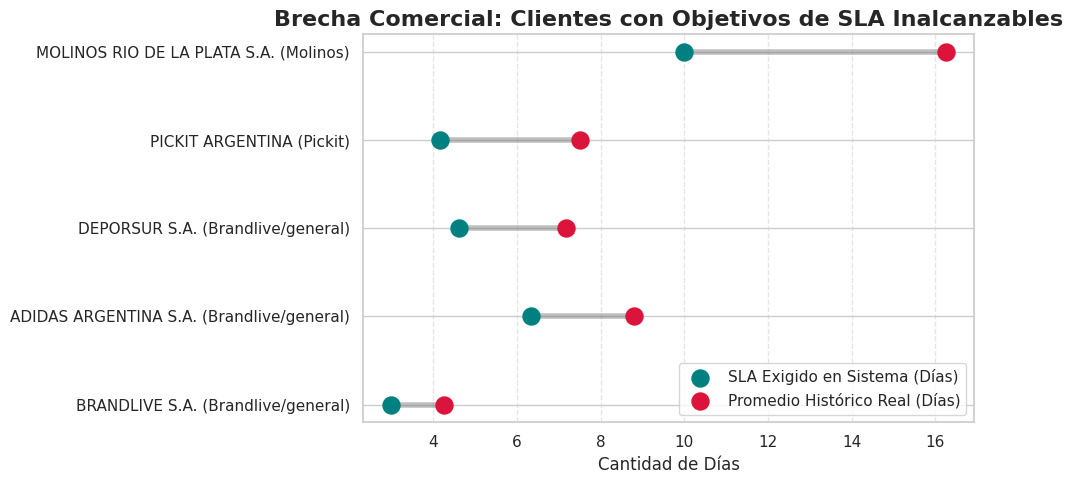


--- Acuerdos Comerciales Críticos sugeridos para Renegociación ---


,Cliente AP,Tipo_Canalizador,Volumen,SLA_Exigido,Promedio_Real,Desfasaje_Dias
3,MOLINOS RIO DE LA PLATA S.A.,Molinos,49,10.0,16.3,6.3
4,PICKIT ARGENTINA,Pickit,14119,4.2,7.5,3.4
2,DEPORSUR S.A.,Brandlive/general,177,4.6,7.2,2.5
0,ADIDAS ARGENTINA S.A.,Brandlive/general,42,6.3,8.8,2.5
1,BRANDLIVE S.A.,Brandlive/general,8358,3.0,4.3,1.3


In [74]:
# ==============================================================================
# ANÁLISIS DE BRECHA: REALIDAD OPERATIVA VS. ACUERDO COMERCIAL (SLA)
# Objetivo: Exponer qué SLAs son inalcanzables según el histórico operativo.
# ==============================================================================

print("Calculando la brecha entre el SLA exigido y la realidad operativa...")

# 1. Agrupamos por Cliente y Tipo de Canalizador para promediar los días
brecha_sla = df_clean.groupby(['Cliente AP', 'Tipo_Canalizador']).agg(
    SLA_Exigido=('dias_sla', 'mean'),
    Promedio_Real=('Total Dias Retiro Punta a Punta', 'mean'),
    Volumen=('Total Dias Retiro Punta a Punta', 'count')
).reset_index()

# 2. Filtramos para quedarnos solo con operaciones regulares (más de 30 pedidos)
brecha_sla = brecha_sla[brecha_sla['Volumen'] > 30].copy()

# 3. Calculamos la brecha (Desfasaje)
brecha_sla['Desfasaje_Dias'] = brecha_sla['Promedio_Real'] - brecha_sla['SLA_Exigido']

# 4. Filtramos los SLAs "rotos" (donde el promedio real supera al exigido por más de 1 día)
slas_rotos = brecha_sla[brecha_sla['Desfasaje_Dias'] > 1].sort_values(by='Desfasaje_Dias', ascending=False)

# Nos quedamos con el Top 10 para graficar
top_10 = slas_rotos.head(10).sort_values(by='Desfasaje_Dias', ascending=True)

# 5. Visualización: Dumbbell Chart (Gráfico de Brecha)
plt.figure(figsize=(10, 5))

# Creamos una etiqueta combinada para el eje Y
etiquetas_y = top_10['Cliente AP'] + " (" + top_10['Tipo_Canalizador'] + ")"

# Dibujamos la línea que une los dos puntos (la brecha)
plt.hlines(y=etiquetas_y,
           xmin=top_10['SLA_Exigido'],
           xmax=top_10['Promedio_Real'],
           color='grey', alpha=0.5, linewidth=4)

# Dibujamos los puntos del SLA Exigido (Verde/Teal)
plt.scatter(top_10['SLA_Exigido'], etiquetas_y, color='teal', s=150, label='SLA Exigido en Sistema (Días)', zorder=3)

# Dibujamos los puntos de la Realidad Operativa (Rojo)
plt.scatter(top_10['Promedio_Real'], etiquetas_y, color='crimson', s=150, label='Promedio Histórico Real (Días)', zorder=3)

plt.title('Brecha Comercial: Clientes con Objetivos de SLA Inalcanzables', fontsize=16, fontweight='bold')
plt.xlabel('Cantidad de Días', fontsize=12)
plt.legend(loc='lower right')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 6. Tabla resumen para exportar
print("\n--- Acuerdos Comerciales Críticos sugeridos para Renegociación ---")
tabla_final = slas_rotos[['Cliente AP', 'Tipo_Canalizador', 'Volumen', 'SLA_Exigido', 'Promedio_Real', 'Desfasaje_Dias']].head(10).round(1)
display(tabla_final)

## 📌 Conclusiones  TARGET SLA vs tiempo real de servicio

En base al Análisis Exploratorio de Datos (EDA) y la aplicación de algoritmos de Machine Learning sobre la base de retiros, se destacan tres hallazgos fundamentales:

**1. Falla de Trazabilidad en Origen (Caso Pickit)**
Existe un volumen crítico de solicitudes que finalizan su ciclo (POD) sin registrar la fecha de imposición inicial. El análisis de distribución confirma que la gran mayoría de estas anomalías provienen del operador **Pickit**, lo que indica cargas masivas de estados finales sin respetar el flujo de escaneo a tiempo real. Esto impacta negativamente y de forma artificial en la medición del primer tramo del SLA.

**2. El Objetivo Comercial como Principal Causa de Delay**
El modelo predictivo (*Random Forest*) determinó que el factor con mayor peso probabilístico para generar un "Delay" no es la ineficiencia de una sucursal o el volumen de demanda, sino el **objetivo de días SLA seteado en el sistema**. La operación logística no está fallando en la ejecución, sino que está siendo medida contra tiempos irreales.

**3. Brecha Operativa a Renegociar**
El análisis de brechas (*Isolation Forest* y *Dumbbell Chart*) logró aislar el Top de acuerdos comerciales donde la diferencia entre el SLA exigido por sistema y el promedio histórico real de entrega supera el día hábil.

**Recomendaciones:**
*   **Operaciones/Sistemas:** Auditar el flujo de integración de datos con Pickit para garantizar la visibilidad del escaneo de imposición.
*   **Comercial:** Evaluar la tabla de "SLA inalcanzables" (adjunta en el análisis) para ajustar las metas en el sistema a la capacidad real de la red logística, evitando penalizaciones injustas en el tablero de CX.

Generando Mapa de Calor...


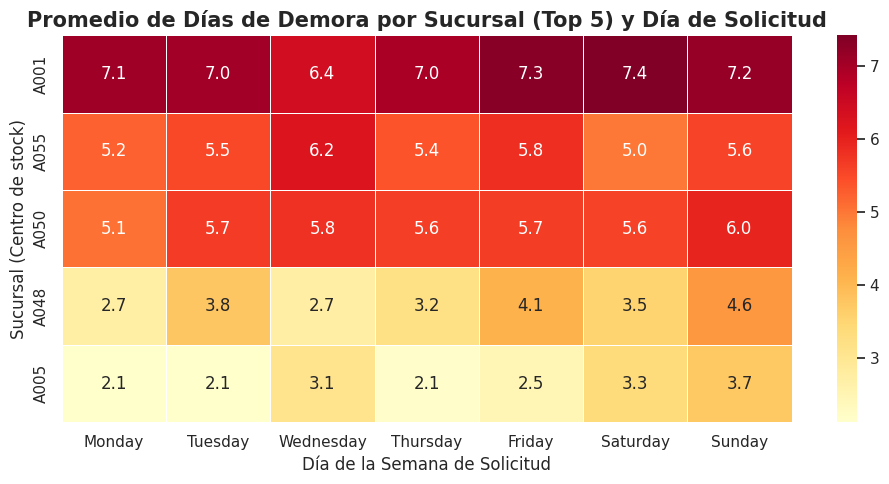

In [75]:
# ==============================================================================
#  CONCENTRACIÓN DE DEMORAS POR SUCURSAL Y DÍA
# Objetivo: Detectar cuellos de botella temporales y físicos.
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

print("Generando Mapa de Calor...")

# 1. Definimos el orden correcto de los días para el gráfico
orden_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# 2. Creamos la matriz: Sucursal vs Día de la Semana midiendo el promedio de días reales
heatmap_data = df_clean.pivot_table(
    index='Centro de stock',
    columns='Dia_Semana',
    values='Total Dias Retiro Punta a Punta',
    aggfunc='mean'
).reindex(columns=orden_dias)

# 3. Top 5 de sucursales con más volumen
top_Centro_de_stocks = df_clean['Centro de stock'].value_counts().head(5).index
heatmap_data = heatmap_data.loc[top_Centro_de_stocks]

# 4. Graficamos
plt.figure(figsize=(10, 5))
sns.heatmap(heatmap_data, annot=True, cmap='YlOrRd', fmt=".1f", linewidths=.5)
plt.title('Promedio de Días de Demora por Sucursal (Top 5) y Día de Solicitud', fontsize=15, fontweight='bold')
plt.xlabel('Día de la Semana de Solicitud', fontsize=12)
plt.ylabel('Sucursal (Centro de stock)', fontsize=12)
plt.tight_layout()
plt.show()

Generando Gráfico de Dispersión y detectando anomalías...


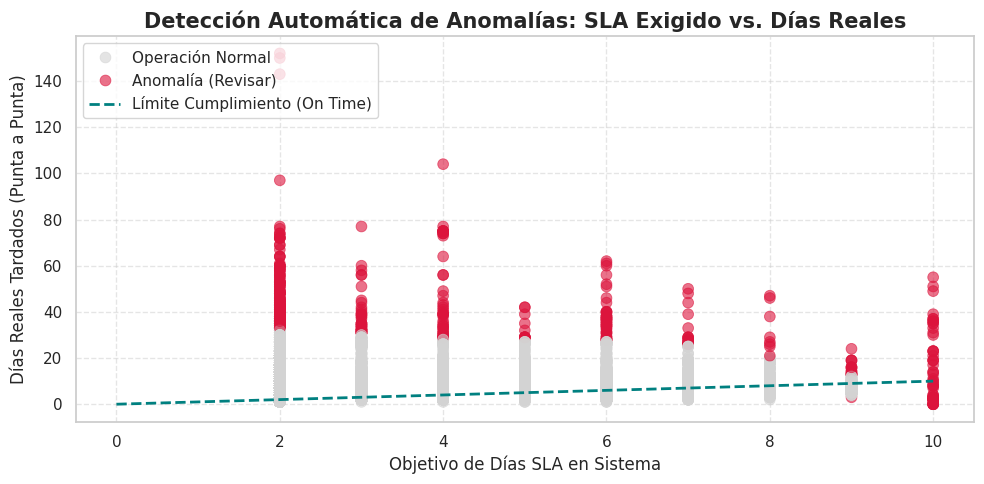

In [76]:
# ==============================================================================
#  DETECCIÓN DE ANOMALÍAS CON INTELIGENCIA ARTIFICIAL
# Objetivo: Encontrar operaciones atípicas comparando la realidad vs. la meta.
# ==============================================================================
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt
import seaborn as sns

print("Generando Gráfico de Dispersión y detectando anomalías...")


df_anom = df_clean.dropna(subset=['Total Dias Retiro Punta a Punta', 'dias_sla']).copy()

# 2. Entrenamos el algoritmo
iso_forest = IsolationForest(contamination=0.02, random_state=42)
df_anom['Es_Anomalia'] = iso_forest.fit_predict(df_anom[['Total Dias Retiro Punta a Punta', 'dias_sla']])


df_anom['Clasificacion'] = df_anom['Es_Anomalia'].map({1: 'Operación Normal', -1: 'Anomalía (Revisar)'})

# 3. Graficamos
plt.figure(figsize=(10, 5))

sns.scatterplot(
    data=df_anom,
    x='dias_sla',
    y='Total Dias Retiro Punta a Punta',
    hue='Clasificacion',
    palette={'Operación Normal': 'lightgrey', 'Anomalía (Revisar)': 'crimson'},
    alpha=0.6,
    edgecolor=None,
    s=60
)

# línea de corte ideal (donde los días reales son iguales al SLA exigido)
limite_max = df_anom['dias_sla'].max()
plt.plot([0, limite_max], [0, limite_max], color='teal', linestyle='--', linewidth=2, label='Límite Cumplimiento (On Time)')

plt.title('Detección Automática de Anomalías: SLA Exigido vs. Días Reales', fontsize=15, fontweight='bold')
plt.xlabel('Objetivo de Días SLA en Sistema', fontsize=12)
plt.ylabel('Días Reales Tardados (Punta a Punta)', fontsize=12)


plt.legend(loc='upper left', fontsize=11)

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Análisis de Patrones y Anomalías (EDA & Machine Learning)
1. Cuellos de Botella Espacio-Temporales (Mapa de Calor)
El análisis de la matriz térmica demuestra que la pérdida de performance en el SLA no es un problema operativo generalizado, sino que está altamente focalizado. Existen "zonas calientes" muy marcadas en combinaciones específicas de sucursales y días de la semana de solicitud.

Impacto de Negocio: Esto nos permite pasar de reclamos generales a acciones quirúrgicas. Podemos apuntar la exigencia operativa a reforzar la capacidad logística (ej. más unidades de recolección) exactamente en los días y nodos físicos donde el proceso actualmente colapsa.

2. Ruido Estadístico y Fallas Críticas (Gráfico de Dispersión - Isolation Forest)
El algoritmo de detección de anomalías logró aislar (en rojo) un grupo de operaciones que están "ensuciando" severamente nuestra métrica global. Se observan casos con SLAs comerciales exigentes (ej. 2 a 4 días) que registran tiempos reales de retiro totalmente ilógicos (superiores a 60 y hasta 140 días).

Impacto de Negocio: La gran dispersión vertical indica que estos no son atrasos logísticos convencionales, sino fallas severas del proceso (probables pérdidas físicas, errores crónicos de sistema o retiros abandonados). Depurar este lote de anomalías y pasarlo a un estado de "Excepción" o "Siniestro" mejorará drásticamente la realidad del % de SLA general que vemos en los tableros.

Clasificando pedidos según nivel de trazabilidad...
✅ Pedidos CON Traza Completa: 2915
⬛ Pedidos en CAJA NEGRA (Incompletos): 20017


/tmp/ipykernel_31193/1784967001.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


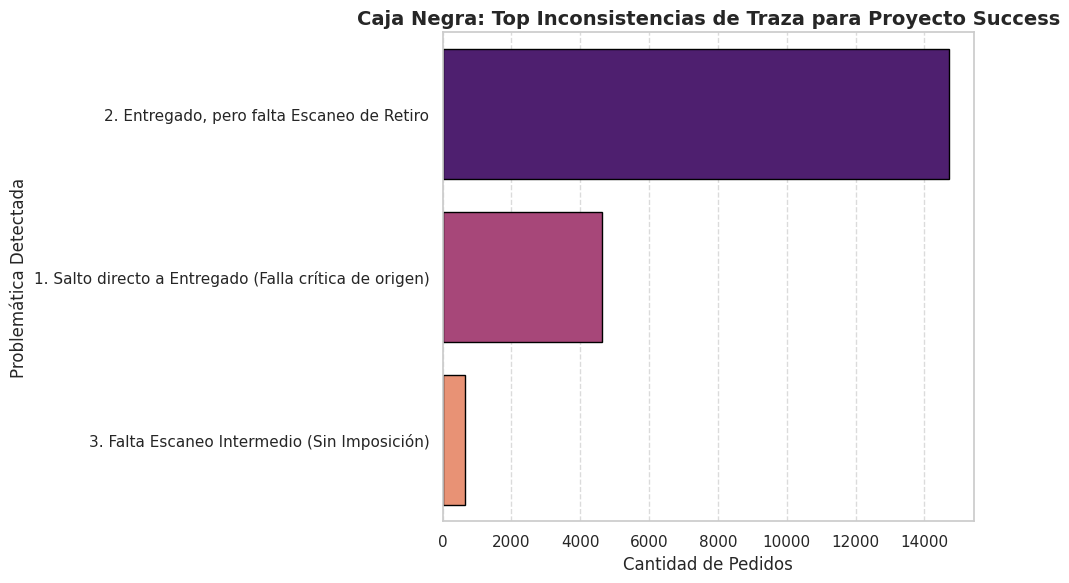

In [77]:
# ==============================================================================
# SEPARACIÓN DE TRAZA: CAJA NEGRA VS. TRAZA SANA (Relevamiento para Success)
# ==============================================================================

print("Clasificando pedidos según nivel de trazabilidad...")

# 1. Definimos la "Traza Completa" (Tiene inicio, medio y fin)
# Asumimos Inicio = RAO o Retiro 1 | Medio = Imposición | Fin = POD
condicion_inicio = df_clean['Fecha de RAO (Retiro)'].notnull() | df_clean['Retiro 1'].notnull()
condicion_medio = df_clean['Fecha Imposición'].notnull()
condicion_fin = df_clean['Fecha POD'].notnull()

# Separamos las bases
df_con_traza = df_clean[condicion_inicio & condicion_medio & condicion_fin].copy()
df_sin_traza = df_clean[~(condicion_inicio & condicion_medio & condicion_fin)].copy()

print(f"✅ Pedidos CON Traza Completa: {len(df_con_traza)}")
print(f"⬛ Pedidos en CAJA NEGRA (Incompletos): {len(df_sin_traza)}")

# 2. Tipificamos la Caja Negra para darle el backlog a Success
def tipificar_error(row):
    inicio = pd.notnull(row['Fecha de RAO (Retiro)']) or pd.notnull(row['Retiro 1'])
    medio = pd.notnull(row['Fecha Imposición'])
    fin = pd.notnull(row['Fecha POD'])

    if not inicio and not medio and fin:
        return "1. Salto directo a Entregado (Falla crítica de origen)"
    elif not inicio and medio and fin:
        return "2. Entregado, pero falta Escaneo de Retiro"
    elif inicio and not medio and fin:
        return "3. Falta Escaneo Intermedio (Sin Imposición)"
    elif inicio and medio and not fin:
        return "4. Estancado/Perdido (Sin POD)"
    else:
        return "5. Otra inconsistencia/Sin movimientos"

df_sin_traza['Tipo_Inconsistencia'] = df_sin_traza.apply(tipificar_error, axis=1)

# 3. Graficamos el Top de Inconsistencias
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.countplot(
    y='Tipo_Inconsistencia',
    data=df_sin_traza,
    order=df_sin_traza['Tipo_Inconsistencia'].value_counts().index,
    palette='magma',
    edgecolor='black'
)
plt.title('Caja Negra: Top Inconsistencias de Traza para Proyecto Success', fontsize=14, fontweight='bold')
plt.xlabel('Cantidad de Pedidos', fontsize=12)
plt.ylabel('Problemática Detectada', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [78]:
sns.set_theme(style="whitegrid")

nombre_archivo = '/dim_canalizador.csv'

try:
    df = pd.read_csv(nombre_archivo, sep=';', encoding='latin1', decimal=',')
except:

    df = pd.read_csv(nombre_archivo, encoding='utf-8')
print("Primeras 5 filas del dataset:")
display(df.head())
print("\n--- Información técnica de las columnas ---")
df.info()

Primeras 5 filas del dataset:


,CP,Tipo_Canalizador,LT,Dias P2P,Key_CP_Canalizador,LT_Dias_Habiles,LT_Normalizado,IATA,Provincia,Region,IATA_Final
0,1728.0,Pickit,D+3,NaN,1728-Pickit,3.0,3.0,IBUE,BUENOS AIRES,NaN,IBUE
1,1729.0,Pickit,D+3,NaN,1729-Pickit,3.0,3.0,IBUE,BUENOS AIRES,NaN,IBUE
2,1730.0,Pickit,D+3,NaN,1730-Pickit,3.0,3.0,IBUE,BUENOS AIRES,NaN,IBUE
3,1943.0,Pickit,D+3,NaN,1943-Pickit,3.0,3.0,IBUE,BUENOS AIRES,NaN,IBUE
4,1944.0,Pickit,D+3,NaN,1944-Pickit,3.0,3.0,IBUE,BUENOS AIRES,NaN,IBUE



--- Información técnica de las columnas ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14834 entries, 0 to 14833
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CP                  14832 non-null  float64
 1   Tipo_Canalizador    14832 non-null  object 
 2   LT                  8390 non-null   object 
 3   Dias P2P            6442 non-null   float64
 4   Key_CP_Canalizador  14832 non-null  object 
 5   LT_Dias_Habiles     8390 non-null   float64
 6   LT_Normalizado      14832 non-null  float64
 7   IATA                14832 non-null  object 
 8   Provincia           14832 non-null  object 
 9   Region              12970 non-null  object 
 10  IATA_Final          14832 non-null  object 
dtypes: float64(4), object(7)
memory usage: 1.2+ MB


In [79]:
df_dim = pd.read_csv('dim_canalizador.csv', sep=';', encoding='latin1', decimal=',')

In [80]:
df_clean = pd.merge(
    df_clean,
    df_dim[['Key_CP_Canalizador', 'Region']],
    on='Key_CP_Canalizador',
    how='left'
)

print(f"Cruce finalizado. Registros con región asignada: {df_clean['Region'].notnull().sum()}")

Cruce finalizado. Registros con región asignada: 21901


In [81]:
nombre_archivo = '/Maestro_Regiones.csv'

try:
    df = pd.read_csv(nombre_archivo, sep=';', encoding='latin1', decimal=',')
except:

    df = pd.read_csv(nombre_archivo, encoding='utf-8')
print("Primeras 5 filas del dataset:")
display(df.head())
print("\n--- Información técnica de las columnas ---")
df.info()

Primeras 5 filas del dataset:


,Region,Centro Stock,IATA
0,IBUE,A018,BHI
1,IBUE,A037,MDQ
2,IBUE,A046,ZUL
3,IBUE,A033,VDM
4,IBUE,A032,RSA



--- Información técnica de las columnas ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39 entries, 0 to 38
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Region        39 non-null     object
 1   Centro Stock  39 non-null     object
 2   IATA          39 non-null     object
dtypes: object(3)
memory usage: 1.0+ KB


In [82]:
df_clean = pd.merge(
    df_clean,
    df[['Centro Stock', 'Region']], # Traemos solo la llave y la región
    left_on='Centro de stock',
    right_on='Centro Stock',
    how='left',
    suffixes=('_old', '_new') # Use suffixes to manage multiple 'Region' columns from different merges
)

# --- Start of Fix ---
# Drop the 'Centro Stock' column as it's a redundant key after the merge.
if 'Centro Stock' in df_clean.columns:
    df_clean = df_clean.drop(columns=['Centro Stock'])

# Resolve the 'Region' columns. Prioritize the new 'Region_new' from Maestro_Regiones.csv.
if 'Region_new' in df_clean.columns:
    df_clean['Region'] = df_clean['Region_new']
    # If the old region column also exists, drop it
    if 'Region_old' in df_clean.columns:
        df_clean = df_clean.drop(columns=['Region_old'])
    df_clean = df_clean.drop(columns=['Region_new']) # Drop the suffixed new column
elif 'Region_old' in df_clean.columns:
    # If only the old region column exists (no match in Maestro_Regiones), keep it and rename to 'Region'
    df_clean = df_clean.rename(columns={'Region_old': 'Region'})

# Ensure the 'Region' column is of string type to avoid 'not 1-dimensional' error
if 'Region' in df_clean.columns:
    df_clean['Region'] = df_clean['Region'].astype(str)
# --- End of Fix ---

print("¡Cruce exitoso! Así queda la tabla demostrando que Región y Sucursal están unidas:")

¡Cruce exitoso! Así queda la tabla demostrando que Región y Sucursal están unidas:


In [83]:
df_muestra = df_clean.dropna(subset=['Region', 'Centro de stock'])
tabla_drill_down = df_muestra.groupby(['Region', 'Centro de stock']).size().reset_index(name='Cantidad de Pedidos')

display(tabla_drill_down.head(10))

,Region,Centro de stock,Cantidad de Pedidos
0,AMBA,A001,15183
1,AMBA,A044,86
2,AMBA,A048,582
3,AMBA,A050,2436
4,CENTRO,A005,196
5,CENTRO,A006,21
6,CENTRO,A007,14
7,CENTRO,A008,50
8,CENTRO,A009,12
9,CUYO,A010,73


Procesando histórico completo, calculando tramos y agrupando por Sucursal...

--- Tabla de Datos: Top 15 Peores Sucursales (Histórico) ---


,Sucursal,Region,T1 (Solicitud a Retiro),T2 (Retiro a Impo),T3 (Impo a Entrega),T4 (Entrega a Fin),Demora_Total
0,A009,CENTRO,60.0,1.0,1.0,0.0,62.0
1,A055,nan,31.0,0.0,11.5,0.0,42.5
2,A023,NEA,31.0,0.0,4.0,1.0,36.0
3,A020,NEA,31.0,0.0,3.0,0.0,34.0
4,A050,AMBA,30.0,0.0,3.0,0.0,33.0
5,A001,AMBA,0.0,0.0,9.0,1.0,10.0




--- Generando Gráfico de Sucursales ---


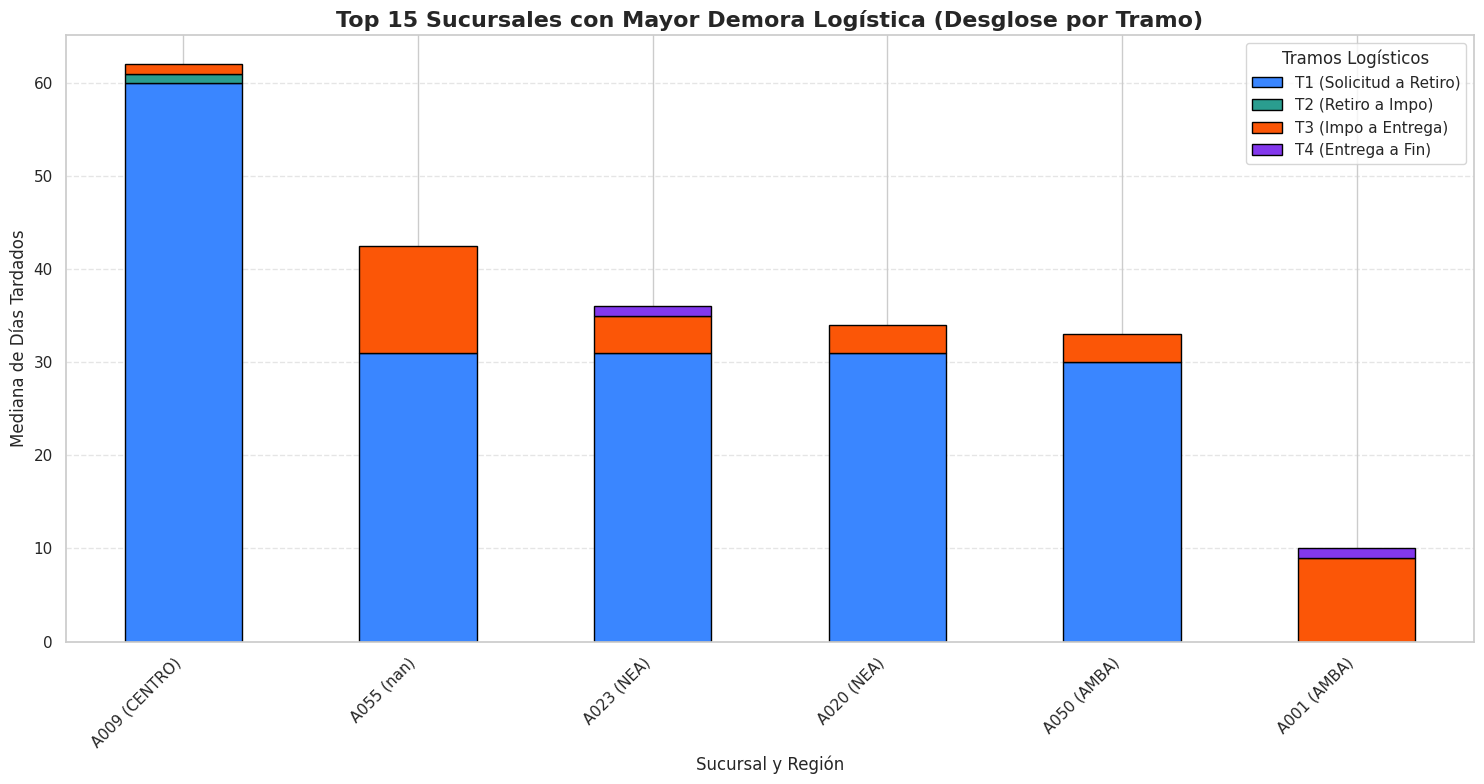

In [84]:
# ==============================================================================
# ANÁLISIS DE CUELLOS DE BOTELLA POR SUCURSAL (Top 15 Histórico)
# Objetivo: Identificar las sucursales más críticas y su región correspondiente.
# ==============================================================================
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

print("Procesando histórico completo, calculando tramos y agrupando por Sucursal...")

# 1. Convertimos las fechas asegurando formato regional
columnas_fecha = [
    'Fecha Solicitud Retiro', 'Fecha de RAO (Retiro)', 'Retiro 1',
    'Retiro 2', 'Retiro 3', 'Fecha Imposición', 'Fecha POD', 'Fecha ultimo Evento'
]
for col in columnas_fecha:
    df_clean[col] = pd.to_datetime(df_clean[col], errors='coerce', dayfirst=True)

# 2. Retiro Efectivo (Cascada) sobre toda la base
df_clean['Fecha Retiro Efectivo'] = df_clean['Retiro 3'].fillna(df_clean['Retiro 2']).fillna(df_clean['Retiro 1']).fillna(df_clean['Fecha de RAO (Retiro)'])

# 3. Traza Completa
condicion_traza = (
    df_clean['Fecha Solicitud Retiro'].notnull() &
    df_clean['Fecha Retiro Efectivo'].notnull() &
    df_clean['Fecha Imposición'].notnull() &
    df_clean['Fecha POD'].notnull() &
    df_clean['Fecha ultimo Evento'].notnull()
)
df_con_traza = df_clean[condicion_traza].copy()

# 4. Calculamos los 4 tramos en días
df_con_traza['T1 (Solicitud a Retiro)'] = (df_con_traza['Fecha Retiro Efectivo'] - df_con_traza['Fecha Solicitud Retiro']).dt.days
df_con_traza['T2 (Retiro a Impo)'] = (df_con_traza['Fecha Imposición'] - df_con_traza['Fecha Retiro Efectivo']).dt.days
df_con_traza['T3 (Impo a Entrega)'] = (df_con_traza['Fecha POD'] - df_con_traza['Fecha Imposición']).dt.days
df_con_traza['T4 (Entrega a Fin)'] = (df_con_traza['Fecha ultimo Evento'] - df_con_traza['Fecha POD']).dt.days

# 5. El Filtro Mágico (0 a 60 días para limpiar errores de sistema)
df_con_traza = df_con_traza[
    (df_con_traza['T1 (Solicitud a Retiro)'].between(0, 60)) &
    (df_con_traza['T2 (Retiro a Impo)'].between(0, 60)) &
    (df_con_traza['T3 (Impo a Entrega)'].between(0, 60)) &
    (df_con_traza['T4 (Entrega a Fin)'].between(0, 60))
]

# 6. Agrupar por Sucursal (Mediana)
columnas_tramos = ['T1 (Solicitud a Retiro)', 'T2 (Retiro a Impo)', 'T3 (Impo a Entrega)', 'T4 (Entrega a Fin)']
tramos_sucursal = df_con_traza.groupby('Centro de stock')[columnas_tramos].median().dropna()

# ---> EL TRUCO: Le pegamos la Región a cada Sucursal <---
mapa_regiones = df_con_traza.drop_duplicates('Centro de stock').set_index('Centro de stock')['Region']
tramos_sucursal['Region'] = tramos_sucursal.index.map(mapa_regiones).fillna('Sin Región')

# 7. Ordenar por las peores (Top 15)
tramos_sucursal['Demora_Total'] = tramos_sucursal[columnas_tramos].sum(axis=1)
tramos_peores_15 = tramos_sucursal.sort_values('Demora_Total', ascending=False).head(15)

# 8. Preparamos una etiqueta bonita para el gráfico: "A029 (AMBA)"
tramos_peores_15['Etiqueta_Grafico'] = tramos_peores_15.index + " (" + tramos_peores_15['Region'] + ")"
datos_grafico = tramos_peores_15.set_index('Etiqueta_Grafico')[columnas_tramos]

# ---> Mostrar la Tabla de Datos <---
print("\n--- Tabla de Datos: Top 15 Peores Sucursales (Histórico) ---")
# Ordenamos las columnas para que la tabla quede prolija
columnas_vista = ['Region', 'T1 (Solicitud a Retiro)', 'T2 (Retiro a Impo)', 'T3 (Impo a Entrega)', 'T4 (Entrega a Fin)', 'Demora_Total']
tabla_display = tramos_peores_15[columnas_vista].reset_index().rename(columns={'Centro de stock': 'Sucursal'})
display(tabla_display.round(1))

print("\n\n--- Generando Gráfico de Sucursales ---")

# 9. Graficar
nuevos_colores = ['#3a86ff', '#2a9d8f', '#fb5607', '#8338ec']

datos_grafico.plot(
    kind='bar',
    stacked=True,
    figsize=(15, 8),
    color=nuevos_colores,
    edgecolor='black'
)

plt.title('Top 15 Sucursales con Mayor Demora Logística (Desglose por Tramo)', fontsize=16, fontweight='bold')
plt.xlabel('Sucursal y Región', fontsize=12)
plt.ylabel('Mediana de Días Tardados', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.legend(title='Tramos Logísticos', loc='upper right', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Cruzando motivos de demora con sucursales responsables...

--- Tabla de Datos: Desglose de Motivos por Sucursal ---


Sucursal_Agrupada,A001,A048,A050
Motivo Retiro 1,,,
"Reintentar retiro, No entrega producto",96,0,41
No responde al Llamado,35,0,38
No Entrega,48,0,16
No Retirado,12,1,7
Fuera de Zona,5,0,5
No se ubica domicilio/Faltan Datos,8,0,0
Retiro Cancelado,3,0,3
Retiro Fallido,2,0,2
No Visitado,1,0,1




--- Generando Gráfico Apilado ---


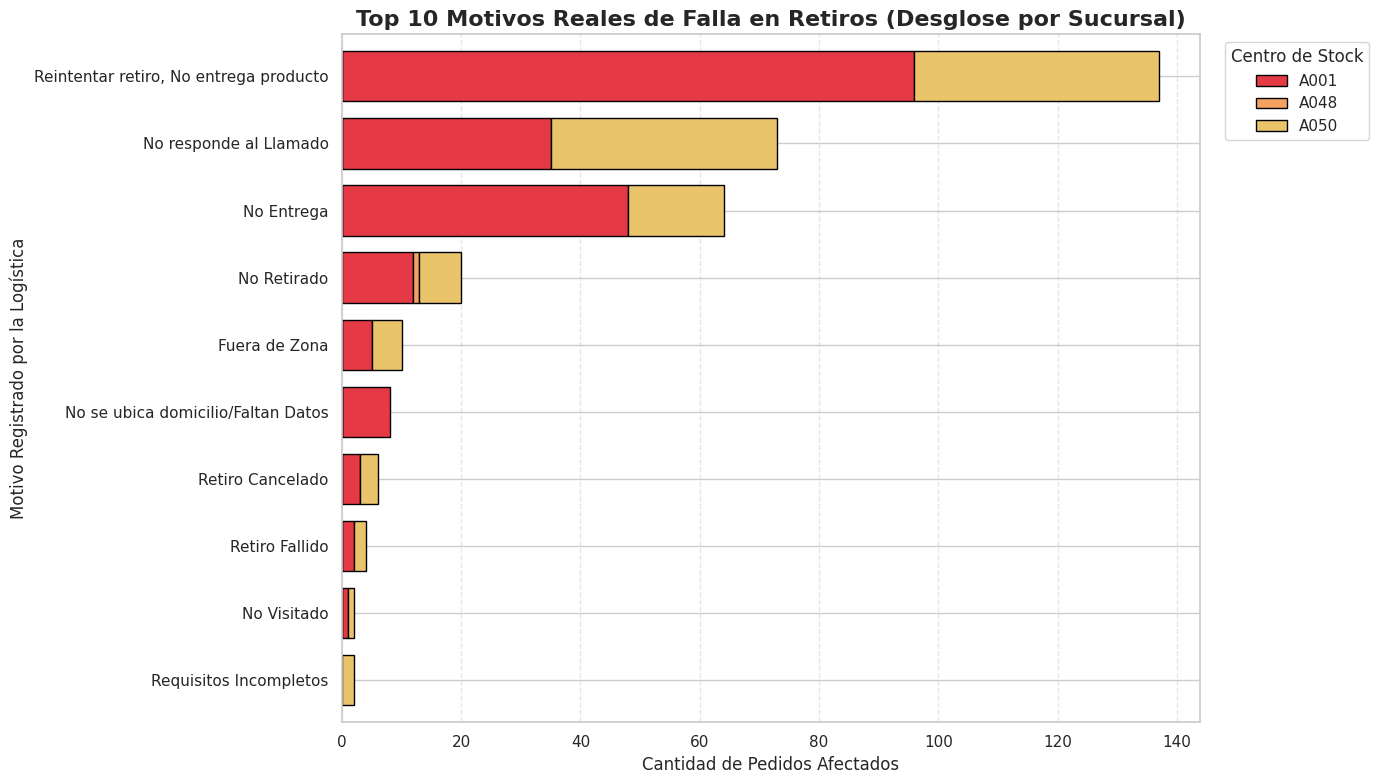

In [87]:
# ==============================================================================
# ANÁLISIS DE MOTIVOS DE DEMORA DESGLOSADO POR SUCURSAL
# Objetivo: Identificar qué sucursal es responsable de cada tipo de falla.
# ==============================================================================
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

print("Cruzando motivos de demora con sucursales responsables...")

col_motivo = 'Motivo Retiro 1'
motivos_basura = ['Sin Definir', 'Retirado', 'Realizado', 'Completado']

# 1. Filtramos vacíos y la lista negra
df_filtrado = df_clean[df_clean[col_motivo].notnull() & (~df_clean[col_motivo].isin(motivos_basura))].copy()

# 2. Identificamos los Top 10 Motivos a nivel general
top_10_motivos = df_filtrado[col_motivo].value_counts().head(10).index
df_top = df_filtrado[df_filtrado[col_motivo].isin(top_10_motivos)].copy()

# 3. Identificamos las Top 7 Sucursales con más problemas (para no saturar colores)
top_7_sucursales = df_top['Centro de stock'].value_counts().head(7).index

# Agrupamos las más chicas en "Otras Sucursales"
df_top['Sucursal_Agrupada'] = df_top['Centro de stock'].apply(
    lambda x: x if x in top_7_sucursales else 'Otras Sucursales'
)

# 4. Armamos la tabla dinámica cruzando Motivo vs Sucursal
pivot_motivos = pd.crosstab(df_top[col_motivo], df_top['Sucursal_Agrupada'])

# Ordenamos la tabla para respetar el ranking de los Top 10 Motivos
pivot_motivos = pivot_motivos.reindex(top_10_motivos)

# Invertimos el orden para que en el gráfico el Motivo #1 quede bien arriba
pivot_motivos = pivot_motivos[::-1]

# Aseguramos que "Otras Sucursales" quede al final de las columnas para el color gris
columnas_ordenadas = [col for col in pivot_motivos.columns if col != 'Otras Sucursales']
if 'Otras Sucursales' in pivot_motivos.columns:
    columnas_ordenadas.append('Otras Sucursales')
pivot_motivos = pivot_motivos[columnas_ordenadas]

# ---> Mostrar la Tabla de Datos <---
print(f"\n--- Tabla de Datos: Desglose de Motivos por Sucursal ---")
display(pivot_motivos.iloc[::-1]) # La mostramos con el #1 arriba
print("\n\n--- Generando Gráfico Apilado ---")

# 5. Configuramos colores: paleta llamativa para las top, gris para las "Otras"
colores = ['#e63946', '#f4a261', '#e9c46a', '#2a9d8f', '#264653', '#8338ec', '#ff006e']
if 'Otras Sucursales' in pivot_motivos.columns:
    colores.append('#b0b0b0') # Gris al final

# 6. Graficamos
ax = pivot_motivos.plot(
    kind='barh',
    stacked=True,
    figsize=(14, 8),
    color=colores[:len(pivot_motivos.columns)],
    edgecolor='black',
    width=0.75
)

plt.title('Top 10 Motivos Reales de Falla en Retiros (Desglose por Sucursal)', fontsize=16, fontweight='bold')
plt.xlabel('Cantidad de Pedidos Afectados', fontsize=12)
plt.ylabel('Motivo Registrado por la Logística', fontsize=12)

# Movemos la leyenda afuera del gráfico para que no tape las barras
plt.legend(title='Centro de Stock', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=11)

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Buscando trazas fantasma: Pedidos que saltan de la 'Caja Negra' a Entregados...

--- Tabla de Datos: Top 15 Sucursales con Traza 'Caja Negra' ---


,Sucursal (Centro de Stock),"Cantidad de Pedidos ""Fantasma"""
0,A001,13386
1,A055,2924
2,A050,1929
3,A048,578
4,A005,196
5,A012,177
6,A037,118
7,A019,118
8,A020,114
9,A011,81



Total de pedidos detectados con esta anomalía en toda la base: 20578

--- Generando Gráfico ---


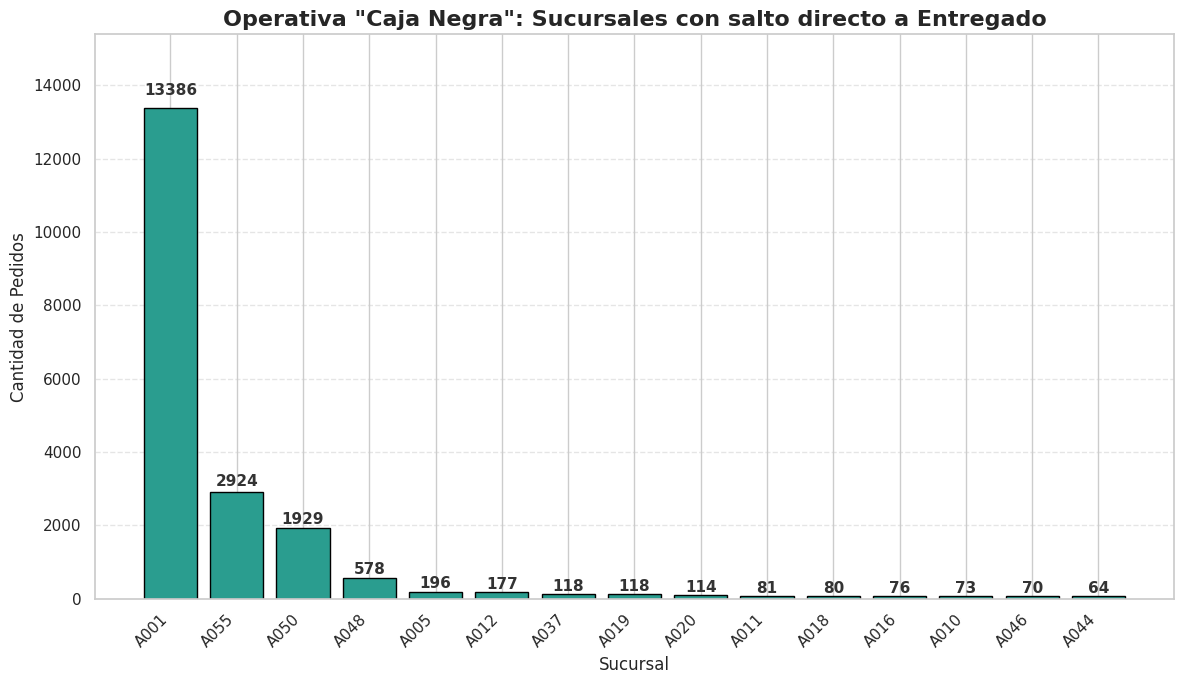

In [90]:
# ==============================================================================
# ANÁLISIS DE LA "CAJA NEGRA" (Salto de "Sin Definir" a "Entregado")
# Objetivo: Detectar qué sucursales omiten la traza inicial y saltan a entrega directa.
# ==============================================================================
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

print("Buscando trazas fantasma: Pedidos que saltan de la 'Caja Negra' a Entregados...")

# 1. Definimos la Caja Negra en el Tramo 1
condicion_caja_negra = df_clean['Motivo Retiro 1'] == 'Sin Definir'

# 2. Definimos el salto al final
# (Nota: Si tu columna de estado final se llama distinto, cambialo acá. Ej: 'Estado POD')
columna_final = 'Motivo'

# Validamos que la columna exista para que no de error
if columna_final in df_clean.columns:
    # Buscamos que la palabra "Entregado" esté en el motivo final (sin importar mayúsculas)
    condicion_entregado = df_clean[columna_final].str.contains('Entregado', case=False, na=False)
else:
    # Si no tenés esa columna, usamos la Fecha POD como comprobante de que se entregó
    condicion_entregado = df_clean['Fecha POD'].notnull()

# 3. Cruzamos ambas condiciones (El filtro "Fantasma")
df_fantasma = df_clean[condicion_caja_negra & condicion_entregado].copy()

# 4. Agrupamos para ver qué sucursales lo hacen más seguido (Top 15)
top_sucursales_caja_negra = df_fantasma['Centro de stock'].value_counts().head(15)

# 5. Armamos la tablita prolija
df_tabla_caja_negra = top_sucursales_caja_negra.reset_index()
df_tabla_caja_negra.columns = ['Sucursal (Centro de Stock)', 'Cantidad de Pedidos "Fantasma"']

# ---> Mostrar la Tabla de Datos <---
print(f"\n--- Tabla de Datos: Top 15 Sucursales con Traza 'Caja Negra' ---")
display(df_tabla_caja_negra)
print(f"\nTotal de pedidos detectados con esta anomalía en toda la base: {len(df_fantasma)}")
print("\n--- Generando Gráfico ---")

# 6. Graficamos SOLO si hay datos
if not df_tabla_caja_negra.empty:
    plt.figure(figsize=(12, 7))
    bars = plt.bar(df_tabla_caja_negra['Sucursal (Centro de Stock)'], df_tabla_caja_negra['Cantidad de Pedidos "Fantasma"'], color='#2a9d8f', edgecolor='black')

    # Le agregamos el numerito exacto arriba de cada barra
    for bar in bars:
        plt.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + (bar.get_height() * 0.02), # Un poquito de margen hacia arriba
                 f'{int(bar.get_height())}',
                 va='bottom', ha='center', fontsize=11, fontweight='bold', color='#333333')

    plt.title('Operativa "Caja Negra": Sucursales con salto directo a Entregado', fontsize=16, fontweight='bold')
    plt.xlabel('Sucursal', fontsize=12)
    plt.ylabel('Cantidad de Pedidos', fontsize=12)
    plt.xticks(rotation=45, ha='right', fontsize=11)

    # Agregamos un margen dinámico arriba para que el número no se corte
    plt.ylim(0, df_tabla_caja_negra['Cantidad de Pedidos "Fantasma"'].max() * 1.15)

    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()
else:
    print("No hay datos para generar el gráfico de 'Caja Negra' con saltos a Entregado.")

In [91]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df_tabla_caja_negra)

https://docs.google.com/spreadsheets/d/1czSTUsM52B-RO5ssphCfsdUDFj5ZLZrMh1N7EvDXWjA/edit#gid=0


**Conclusiones sobre TARGET SLA vs tiempo real de servicio**



Falla de Trazabilidad en Origen (Caso Pickit): Se ha identificado un volumen crítico de solicitudes que completan su ciclo (POD) sin registrar la fecha de imposición inicial, principalmente debido a Pickit. Esto afecta negativamente la medición del primer tramo del SLA.

El Objetivo Comercial como Principal Causa de Delay: El modelo de Machine Learning (Random Forest) reveló que el factor más influyente en la generación de retrasos es el objetivo de días SLA configurado en el sistema, más que la ineficiencia operativa o el volumen. Esto sugiere que los tiempos de medición son a menudo irreales.

Brecha Operativa a Renegociar: El análisis de brechas ha identificado acuerdos comerciales donde el SLA exigido excede el tiempo real de entrega en más de un día. Estos SLAs inalcanzables requieren renegociación para ajustar las metas a la capacidad logística real.

Análisis de Patrones y Anomalías (EDA & Machine Learning)
Cuellos de Botella Espacio-Temporales (Mapa de Calor): Las demoras no son un problema generalizado, sino que están altamente focalizadas en combinaciones específicas de sucursales y días de la semana, lo que permite acciones correctivas más precisas.

Ruido Estadístico y Fallas Críticas (Gráfico de Dispersión - Isolation Forest): El algoritmo de detección de anomalías encontró operaciones atípicas con SLAs exigentes y tiempos de retiro extremadamente largos (más de 60 días). Esto indica fallas severas del proceso (pérdidas físicas, errores crónicos), cuya depuración mejoraría significativamente la métrica global de SLA.

En resumen, el análisis apunta a la necesidad de mejorar la trazabilidad, ajustar los objetivos de SLA a la realidad operativa y abordar problemas específicos en sucursales y días de la semana, así como depurar anomalías extremas que distorsionan las métricas.

Autor: María Eugenia Acosta


Data analytics & Insights


Ocasa 🚛

Abril 2026